In [19]:
#Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
#Importação do Dataset resultante do CP de AICSS
path = '/content/drive/MyDrive/FIAP/CP2_MachineLearning/BaseAICSS_CP2.csv'
df_aicss = pd.read_csv(path)
display(df_aicss)

,ID,Distancia_cm,Temperatura_C,Status
0,1,400.00,24.0,SEGURO
1,2,16.09,24.0,INSEGURO
2,3,117.99,24.0,SEGURO
3,4,117.99,24.0,SEGURO
4,5,117.99,24.0,SEGURO
...,...,...,...,...
102,103,252.16,37.5,INSEGURO
103,104,58.48,37.5,INSEGURO
104,105,189.63,37.5,INSEGURO
105,106,189.63,37.5,INSEGURO


### Estatísticas Descritivas Gerais

In [22]:
display(df_aicss.describe())

#Média de temperatura próxima a mediana, distribuição centralizada
#No entanto, a amplitude é bem alta, o que sugere ruído no sensor ou condições extremas
#Desvio padrão de distância alto, indica que os objetos detectados estão em distâncias bem diferentes ou tem muita variação de movimento

,ID,Distancia_cm,Temperatura_C
count,107.000000,107.000000,107.000000
mean,54.000000,108.835047,21.811215
std,31.032241,72.826731,14.737920
min,1.000000,2.010000,-14.300000
25%,27.500000,72.600000,10.300000
50%,54.000000,117.990000,24.000000
75%,80.500000,141.200000,33.300000
max,107.000000,400.000000,53.700000


### Estatísticas Descritivas por Classe (Status)

In [23]:
display(df_aicss.groupby('Status').describe())

#Temperatura é o maior diferenciador
#Classe INSEGURO tem a maioria dos dados acima de 25°C
#Classe SEGURO tem valor máximo de 29.9°C, o que reforça o limite de segurança estabelecido de 30°C

#Para a distância, o valor mínimo de 2cm também fica visível

ID                                                        \
         count       mean        std  min    25%   50%    75%    max   
Status                                                                 
INSEGURO  44.0  52.772727  31.945348  2.0  23.75  48.5  72.25  106.0   
SEGURO    63.0  54.857143  30.607746  1.0  30.50  56.0  81.50  107.0   

         Distancia_cm              ...                 Temperatura_C  \
                count        mean  ...      75%    max         count   
Status                             ...                                 
INSEGURO         44.0   89.447955  ...  136.655  400.0          44.0   
SEGURO           63.0  122.375238  ...  142.705  400.0          63.0   

                                                               
               mean        std   min   25%   50%    75%   max  
Status                                                         
INSEGURO  32.122727  14.277399   1.0  25.6  36.7  38.15  53.7  
SEGURO    14.609524  10.090489 -14.3  10.3  13.7  24.80  29.9  

[2 rows x 24 columns]

### Geração de gráfico

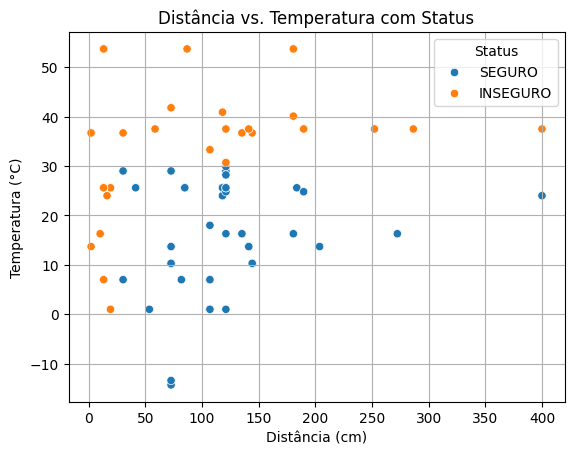

In [24]:
#Classificação
sns.scatterplot(data=df_aicss, x='Distancia_cm', y='Temperatura_C', hue='Status')
plt.title('Distância vs. Temperatura com Status')
plt.xlabel('Distância (cm)')
plt.ylabel('Temperatura (°C)')
plt.grid(True)
plt.show()

### Pré-processamento de Dados: Verificação de Dados Faltantes e Inconsistências

In [25]:
#Verificando dados faltantes
print("Valores Nulos por Coluna:")
display(df_aicss.isnull().sum())

Valores Nulos por Coluna:


,0
ID,0
Distancia_cm,0
Temperatura_C,0
Status,0


In [26]:
# Verificando tipos de dados e informações gerais do DataFrame
print("Informações do DataFrame (Tipos de Dados e Não-Nulos):")
df_aicss.info()

Informações do DataFrame (Tipos de Dados e Não-Nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             107 non-null    int64  
 1   Distancia_cm   107 non-null    float64
 2   Temperatura_C  107 non-null    float64
 3   Status         107 non-null    object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.5+ KB


### Divisão dos Dados em Conjuntos de Treinamento e Teste

In [27]:
#Divisão de dados
X = df_aicss[['Distancia_cm', 'Temperatura_C']]
y = df_aicss['Status']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42) #20% pra teste, 80% para treinamento

In [28]:
#Treinamento
from sklearn.linear_model import LogisticRegression

#Inicializar o classificador de Regressão Logística
modelo_lr = LogisticRegression(random_state=42)

#Treinar o modelo com os dados de treinamento
modelo_lr.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


###Testes

In [29]:
#Realiza a previsão com os dados de teste
y_predict = modelo_lr.predict(X_teste)

In [30]:
#Realiza a previsão com os dados de treinamento
y_pred_train = modelo_lr.predict(X_treino)

###Avaliação do Modelo: Acurácia, Relatório de Classificação, Matriz de Confusão

In [31]:
from sklearn.metrics import accuracy_score
acuracia = accuracy_score(y_teste, y_predict)
print(f'Acurácia do modelo: {acuracia:.2f}')

Acurácia do modelo: 0.73


In [32]:
acuracia_train = accuracy_score(y_treino, y_pred_train)
print(f'Acurácia com dados de treino do modelo: {acuracia_train:.2f}')

Acurácia com dados de treino do modelo: 0.81


In [33]:
from sklearn.metrics import classification_report, confusion_matrix

#Gerar o relatório de classificação
report = classification_report(y_teste, y_predict)
print("Relatório de Classificação:\n", report)
#Precision = equivale à quantos acertos ele teve (das condições apontadas como inseguras, quantas realmente eram inseguras?)
#Recall = abrangência (das condições inseguras, quantas ele conseguiu detectar?)

Relatório de Classificação:
               precision    recall  f1-score   support

    INSEGURO       0.50      0.83      0.62         6
      SEGURO       0.92      0.69      0.79        16

    accuracy                           0.73        22
   macro avg       0.71      0.76      0.71        22
weighted avg       0.80      0.73      0.74        22



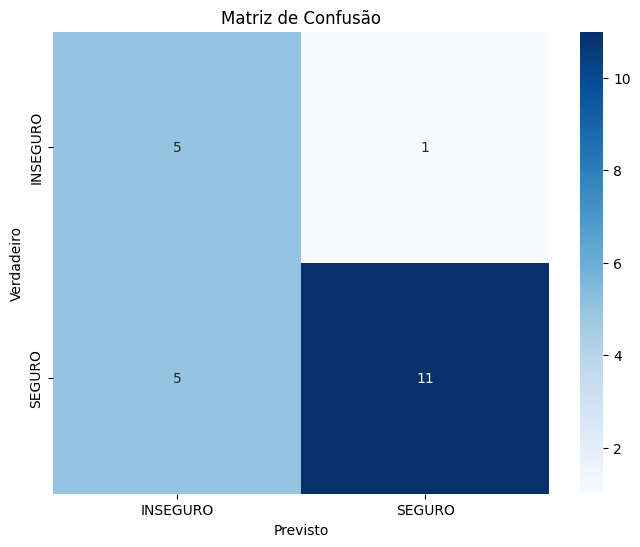

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Gerar a matriz de confusão
conf_matrix = confusion_matrix(y_teste, y_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_lr.classes_, yticklabels=modelo_lr.classes_)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão')
plt.show()

#Classe INSEGURO
#Verdadeiros positivos = modelo previu "inseguro" e era "inseguro"
#Falsos negativos = modelo previu "seguro" mas era "inseguro"
#Recall = 5/(5+1) = 0,83% (recall ok para classificação de risco)
#Precisão = 5/(5+5) = 0,5% (gera mais "alarmes falsos")

#Classe SEGURO
#Verdadeiros positivos = modelo previu "seguro" e era "seguro"
#Falsos positivos = modelo previu "inseguro" mas era "seguro"
#Recall = 11/(11+5) = 0,68%
#Precisão = 11/(11+1) = 0,91%
